In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)
n = 2000

df = pd.DataFrame({
    'Damage': np.random.uniform(10, 150, n),
    'FireRate': np.random.uniform(100, 1200, n),
    'Accuracy': np.random.uniform(1, 100, n),
    'Recoil': np.random.uniform(1, 100, n),
    'Range': np.random.uniform(20, 1000, n),
    'MagazineSize': np.random.randint(1, 101, n),
    'Weight': np.random.uniform(1, 15, n),
    'Rarity': np.random.randint(1, 6, n),
})


price = (df['Damage'] * 25 + df['FireRate'] * 0.5 + df['Accuracy'] * 10 + df['Range'] * 2 + df['MagazineSize'] * 10 - df['Recoil'] * 5 - df['Weight'] * 30) *(1 + (df['Rarity'] - 1) * 0.3) + np.random.normal(loc=0, scale=5, size=n)
df['Price'] = price 
df['Price'] = df['Price'].clip(lower=50)

In [2]:
print(df.head())

       Damage     FireRate   Accuracy     Recoil       Range  MagazineSize  \
0   62.435617   387.876252  57.627592  65.177438  725.862565            55   
1  143.100003   371.676679  80.737801  18.066250  693.537344            96   
2  112.479152  1096.880039  76.255932  87.367062  113.839115            36   
3   93.812188   374.500820  16.236091  61.698508  924.120957            37   
4   31.842610   399.144699  15.775698  16.563184  577.102758            14   

      Weight  Rarity        Price  
0   8.460465       4  7127.128391  
1  11.627490       2  8422.804165  
2  11.682848       1  3928.155219  
3  10.300955       2  5584.105567  
4   4.441737       3  3567.660485  


In [3]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Damage        2000 non-null   float64
 1   FireRate      2000 non-null   float64
 2   Accuracy      2000 non-null   float64
 3   Recoil        2000 non-null   float64
 4   Range         2000 non-null   float64
 5   MagazineSize  2000 non-null   int32  
 6   Weight        2000 non-null   float64
 7   Rarity        2000 non-null   int32  
 8   Price         2000 non-null   float64
dtypes: float64(7), int32(2)
memory usage: 125.1 KB
None


In [4]:
print(df.describe())

            Damage     FireRate     Accuracy       Recoil        Range  \
count  2000.000000  2000.000000  2000.000000  2000.000000  2000.000000   
mean     79.809170   646.029426    50.132206    49.296133   501.812921   
std      40.909512   317.437885    28.506164    28.444119   276.526892   
min      10.450557   100.012798     1.003041     1.023859    20.051770   
25%      43.326506   375.865435    25.446578    24.693685   268.197079   
50%      81.029178   641.963760    49.659564    48.935683   496.969758   
75%     115.095036   923.559561    74.245326    73.976228   735.090043   
max     149.960474  1199.513474    99.935680    99.946607   999.515086   

       MagazineSize       Weight      Rarity         Price  
count   2000.000000  2000.000000  2000.00000   2000.000000  
mean      50.592000     8.029996     2.97250   6115.665772  
std       28.727272     4.015520     1.41483   2609.728427  
min        1.000000     1.001661     1.00000    387.583943  
25%       25.000000     4.59

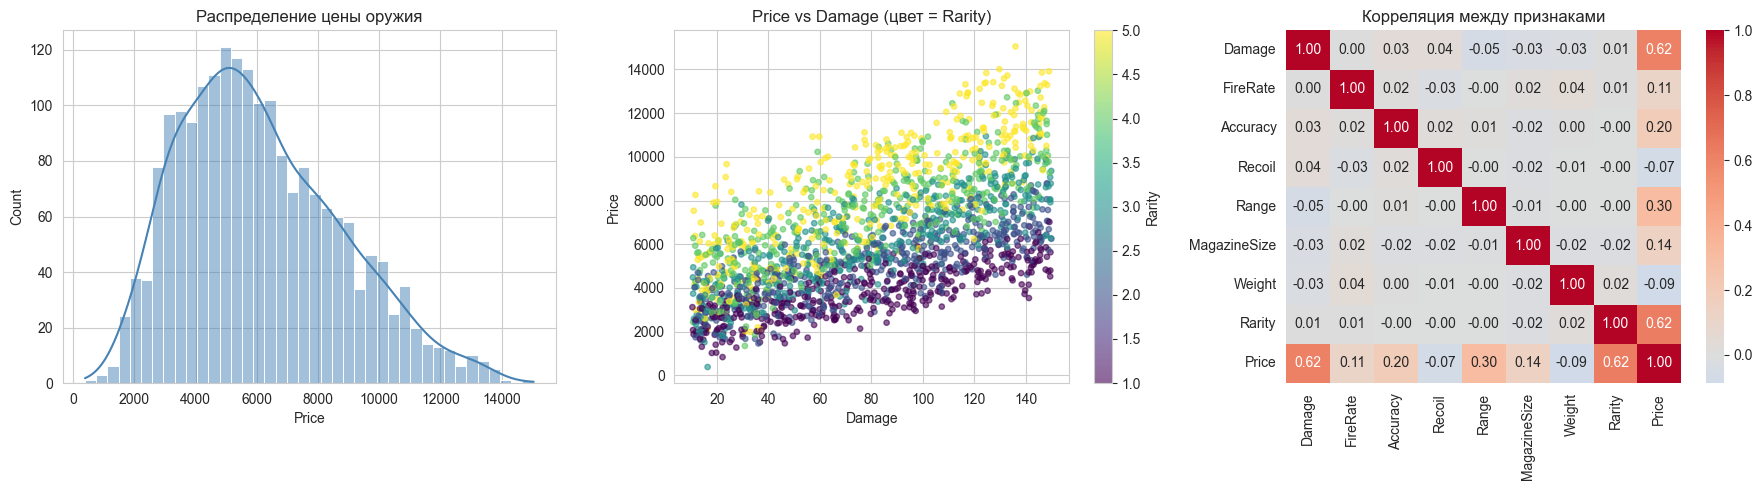

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['Price'], bins=40, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Распределение цены оружия')
axes[0].set_xlabel('Price')

scatter = axes[1].scatter(df['Damage'], df['Price'], c=df['Rarity'], cmap='viridis', alpha=0.6, s=15)
axes[1].set_title('Price vs Damage (цвет = Rarity)')
axes[1].set_xlabel('Damage')
axes[1].set_ylabel('Price')
fig.colorbar(scatter, ax=axes[1], label='Rarity')

corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[2])
axes[2].set_title('Корреляция между признаками')

plt.tight_layout()
plt.show()

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X = df.drop('Price', axis=1)
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")
print(f"R2: {r2_score(y_test, y_pred):.4f}")

MAE: 398.39
MSE: 297253.23
R2: 0.9579
